# Case study: Qualitative analysis and quantitative analysis on the polarization test
This manuscript aims to investigate the phenomenon of the observed higher concentration loss at high temperature.

Recall the last discussion, we draw the following argument:
1. At high temperature, the temperature of the humidifier supply didn't match the stack temperature which was well controller by the cooling circuit.
2. The vapor condense immediately at the interface, and thus we can observe a higher concentration loss at high temperature

Another possibility may be also exist: 

3. According to some existing literature, oxygen resistance was found became higher when the RH was low. Thus, at the 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import re
from scipy.integrate import solve_ivp
from pathlib import Path
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *
from data.load_experiment import load_aux_data_exp

In [4]:
aux_path = project_root / "data" / "auxiliary.xlsx"
xls = pd.ExcelFile(aux_path)
aux_data_exp = {sheet: pd.read_excel(aux_path, sheet_name=sheet) for sheet in xls.sheet_names}

Firstly, the humidity sensor data is supporting the argument above:

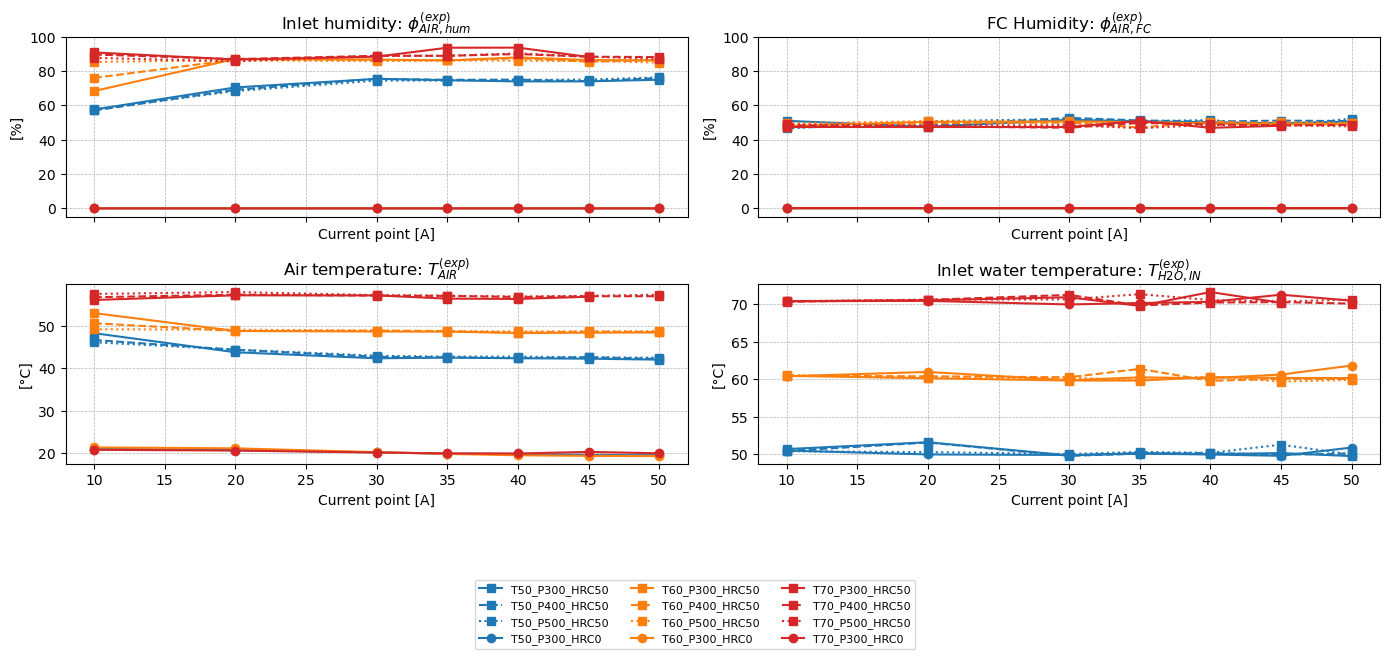

In [16]:
mean_by_condition = {}
for condition, df in aux_data_exp.items():
    summary = df.assign(I_POINT=df["I_LOAD"].round()).groupby("I_POINT", as_index=False)[["HR_AIR_Gaz", "HR_AIR_FC","T_AIR", "T_H2O_IN"]].mean().sort_values("I_POINT")
    mean_by_condition[condition] = summary

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 6), sharex=True)
for condition, summary in mean_by_condition.items():
    t = int(re.search(r"T(\d+)", condition).group(1))
    p_bar = {300: 1.3, 400: 1.4, 500: 1.5}[int(re.search(r"P(\d+)", condition).group(1))]
    rh_frac = int(re.search(r"HRC(\d+)", condition).group(1)) / 100
    init_cond_key = f"RHA0/RHC{rh_frac:g}_P{p_bar:.1f}_T{t}"
    props = get_plot_properties(init_cond_key)
    axes[0, 0].plot(summary["I_POINT"], summary["HR_AIR_Gaz"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)
    axes[0, 1].plot(summary["I_POINT"], summary["HR_AIR_FC"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)
    axes[1, 0].plot(summary["I_POINT"], summary["T_AIR"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)
    axes[1, 1].plot(summary["I_POINT"], summary["T_H2O_IN"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)

for ax in axes.flatten():
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.set_xlabel("Current point [A]")
axes[0, 0].set_title(r"Inlet humidity: $\phi_{AIR, hum}^{(exp)}$")
axes[0, 0].set_xlabel("Current point [A]")
axes[0, 0].set_ylabel(r"[%]")
axes[0, 1].set_title(r"FC Humidity: $\phi_{AIR,FC}^{(exp)}$")
axes[0, 1].set_ylabel(r"[%]")
axes[1, 0].set_title(r"Air temperature: $T_{AIR}^{(exp)}$")
axes[1, 0].set_ylabel(r"[°C]")
axes[1, 1].set_title(r"Inlet water temperature: $T_{H2O,IN}^{(exp)}$")
axes[1, 1].set_ylabel(r"[°C]")
axes[0, 0].set_ylim(-5, 100)
axes[0, 1].set_ylim(-5, 100)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=8, frameon=True)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

The temperature of the humidifier is responded to the humidity reference signal, by controlling the amount of water molecular at the inlet. The humidity actuator doesn't take charge of the temperature of the vapor at the supply manifold. The temperature at this position can be much lower than the stack operation voltage. 

The low temperature condition at the gas channel may lead to high concentration loss at high temperature for the reason:

1. The generated water from the eletrode may condense near the interface due to the local temperature.
2. The vapor in the gas channel may accelerate the thermal exchange.

##